> **Note:** This environment variable is required for fully deterministic CuBLAS ops on CUDA >= 10.2 when `reproducible=True` is set below. Without it, PyTorch raises a `RuntimeError` instead of training deterministically. It must be set before `torch` is imported. See the [README FAQ](../../README.md#reproducibility-and-cublas_workspace_config) for details.

In [16]:
%env CUBLAS_WORKSPACE_CONFIG=:16:8

env: CUBLAS_WORKSPACE_CONFIG=:16:8


# How to Train and Use Disentanglix: A Disentangled VAE

`Disentanglix` is a variant of the `Varix` pipeline that implements a **disentangled variational autoencoder**.  
Its key difference lies in the loss function, which decomposes the standard VAE loss into subcomponents to encourage disentanglement in the latent space with independent latent dimensions.


**IMPORTANT**

> This tutorial only shows the specifics of the Disentanglix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the `Getting Started - Vanillix` tutorial first.




## What You'll Learn

- How the loss decomposes into:
  - **Reconstruction loss** (`recon_loss`)  
  - **Mutual information** (`mut_info_loss`)  
  - **Total correlation** (`tot_corr_loss`)  
  - **Dimension-wise KL divergence** (`dimwise_kl_loss`)  
- How annealing can be applied to disentanglement weights (`beta_mi`, `beta_tc`, `beta_dimKL`)  
- How to initialize, run and visualize a disentangled VAE


## 1) Loss Decomposition

The `DisentanglixLoss` class computes the following terms for each batch:

1. **Reconstruction Loss** (`recon_loss`)  
   Measures how well the decoded output matches the input.

2. **Mutual Information Loss** (`mut_info_loss`)  
   Encourages each latent dimension to encode information about the inputs.

3. **Total Correlation Loss** (`tot_corr_loss`)  
   Penalizes correlations between latent dimensions to encourage independence.

4. **Dimension-wise KL Loss** (`dimwise_kl_loss`)  
   Regularizes each latent dimension individually against the prior.

The total loss is computed as a weighted sum:
```python
total_loss = recon_loss 
             + beta_mi * mut_info_loss 
             + beta_tc * tot_corr_loss 
             + beta_dimKL * dimwise_kl_loss
```

## 2) Annealing

Disentanglix supports flexible annealing strategies:

- no-annealing: uses constant weights throughout training

- Custom annealing functions: scales the disentanglement weights according to the current epoch

Annealing is applied independently to each loss term, allowing smooth transitions between reconstruction-focused and disentanglement-focused training.


## Requirements 1: Be in the correct directory (execute below)


In [17]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /home/ewald/Github/autoencodix_package


## Requirements 2: Obtain tutorial data or use own data
We use real human lung single-cell RNA-seq data assembled from the [CZ CELLxGENE Census](https://cellxgene.cziscience.com/). It is hosted on Hugging Face Hub ([autoencodix/census-lung](https://huggingface.co/datasets/autoencodix/census-lung)) and is downloaded automatically in the cells below on first run. The full dataset contains ~89,000 cells spanning four lung cell types (malignant cells, pulmonary alveolar type 2 cells, respiratory basal cells, alveolar macrophages), which also correlate closely with the `disease` metadata column (normal / lung adenocarcinoma / cystic fibrosis). We use `cell_type` and `disease` as the two factors to inspect for disentanglement below. To keep this tutorial fast to run, we draw a balanced subsample of 2,000 cells per cell type.


## 3) Initialize and Run Disentanglix
This works like `Varix`, except we don't have one `beta` parameter to weight the distribution loss, we have three `betas` one for each sub loss term which we can set a value for in the config.

In [18]:
import numpy as np
import anndata as ad
import mudata

from autoencodix.configs.disentanglix_config import DisentanglixConfig
from autoencodix.configs.default_config import DataCase, DataConfig, DataInfo
from autoencodix.data.datapackage import DataPackage
from huggingface_hub import hf_hub_download
import autoencodix as acx

sc_path = hf_hub_download(
    repo_id="autoencodix/census-lung", repo_type="dataset", filename="census_lung.h5ad"
)
full_adata = ad.read_h5ad(sc_path)

# Balanced subsample: 2,000 cells per cell type keeps the tutorial fast to run
# while keeping all four (well-separated) cell types equally represented.
N_PER_TYPE = 2000
rng = np.random.RandomState(43)
subsample_idx = []
for _, group in full_adata.obs.groupby("cell_type", observed=True):
    n = min(N_PER_TYPE, len(group))
    subsample_idx.extend(rng.choice(group.index.values, size=n, replace=False))

adata = full_adata[subsample_idx].copy()

sc_data = DataPackage()
sc_data.multi_sc = {"multi_sc": mudata.MuData({"rna": adata})}

my_cfg = DisentanglixConfig(
	data_case=DataCase.MULTI_SINGLE_CELL,
	loss_reduction="sum",
	k_filter=2000,
	latent_dim=2,
	scaling="STANDARD",
	epochs=50,
	learning_rate=0.01,
	batch_size = 128,
	beta_mi = 0.1,
	beta_tc = 0.1,
	beta_dimKL= 0.1,
	use_mss = True,
	drop_p =0.1,
	global_seed=43,
	reproducible=True,
	checkpoint_interval=10,
	n_layers=1,
	annotation_columns=["cell_type", "disease"],
	data_config=DataConfig(
		data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
	),
)

disent = acx.Disentanglix(data=sc_data, config=my_cfg)


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


In [19]:
result = disent.run()

mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc
Processing valid split
Processing

/home/ewald/Github/autoencodix_package/src/autoencodix/trainers/_general_trainer.py:233: UserWarning: Gradient clipping was first applied in epoch 0. Total norm of gradients (adjusted for number of features): 34.6528 exceeded max norm of 5.
  warnings.warn(


Epoch 10 - Train Loss: 1726.3673
Sub-losses: recon_loss: 1725.3369, mut_info_loss: 0.0007, tot_corr_loss: 0.0003, dimwise_kl_loss: 1.0293, anneal_factor: 0.0017, effective_beta_mi_factor: 0.0002, effective_beta_tc_factor: 0.0002, effective_beta_dimKL_factor: 0.0002
Epoch 10 - Valid Loss: 1673.8871
Sub-losses: recon_loss: 1672.8742, mut_info_loss: 0.0007, tot_corr_loss: 0.0003, dimwise_kl_loss: 1.0119, anneal_factor: 0.0017, effective_beta_mi_factor: 0.0002, effective_beta_tc_factor: 0.0002, effective_beta_dimKL_factor: 0.0002
Epoch 20 - Train Loss: 1725.8379
Sub-losses: recon_loss: 1718.8209, mut_info_loss: 0.0321, tot_corr_loss: 0.0090, dimwise_kl_loss: 6.9759, anneal_factor: 0.0832, effective_beta_mi_factor: 0.0083, effective_beta_tc_factor: 0.0083, effective_beta_dimKL_factor: 0.0083
Epoch 20 - Valid Loss: 1670.5746
Sub-losses: recon_loss: 1664.1757, mut_info_loss: 0.0319, tot_corr_loss: 0.0085, dimwise_kl_loss: 6.3585, anneal_factor: 0.0832, effective_beta_mi_factor: 0.0083, effect

#### 3.1) Obtain Results

This works as for other pipeline, but we have more sub-losses. See below:

In [20]:
result.sub_losses.keys()

dict_keys(['recon_loss', 'mut_info_loss', 'tot_corr_loss', 'dimwise_kl_loss', 'anneal_factor', 'effective_beta_mi_factor', 'effective_beta_tc_factor', 'effective_beta_dimKL_factor'])

#### 3.2) Visualize Results
In principle this also works the same as for `Varix`. However, me might be interested in a relative loss plot since we more different loss types.

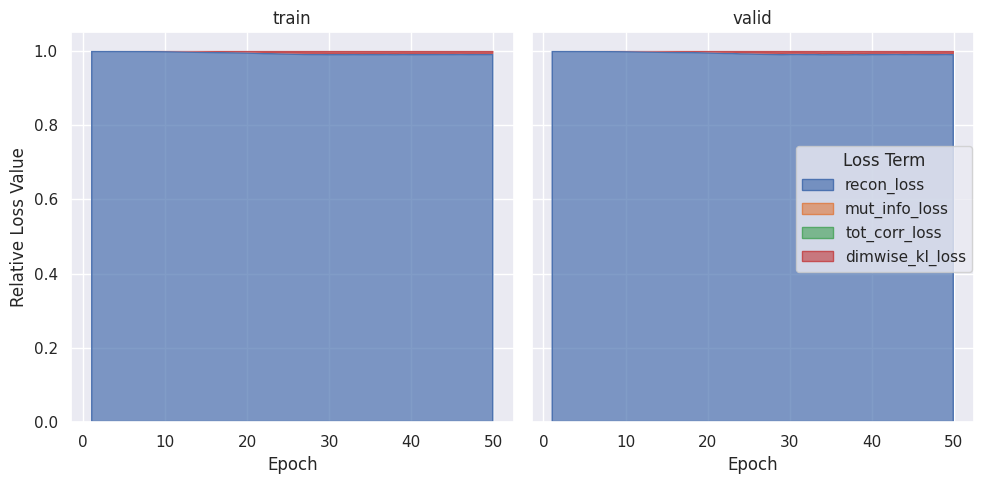

In [21]:

disent.visualizer.show_loss(plot_type="relative")

We can visualize our standard plots with `show_result`:


Creating plots ...


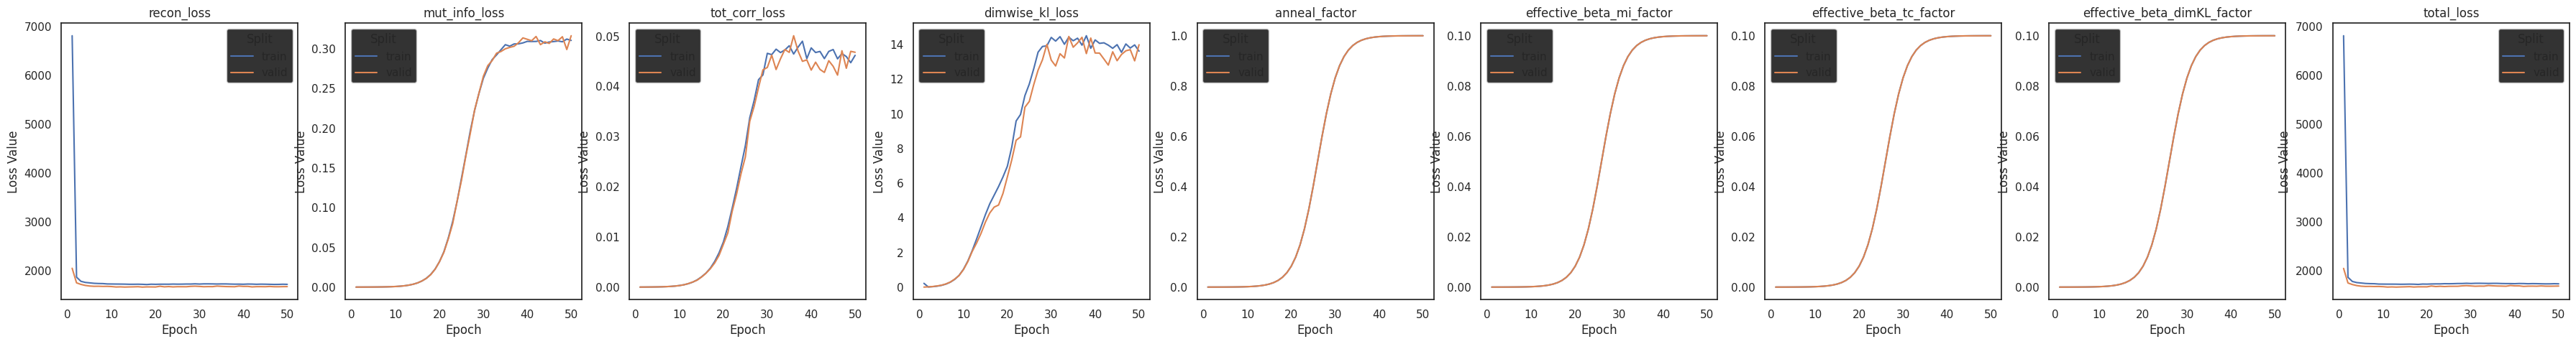

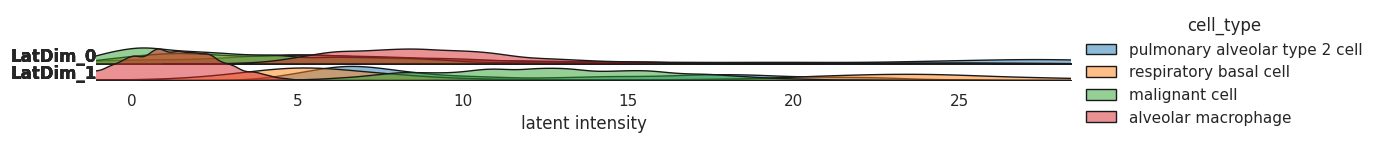

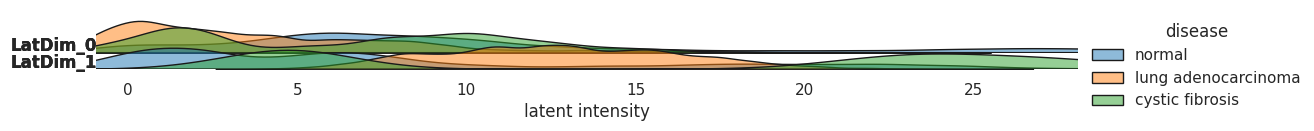

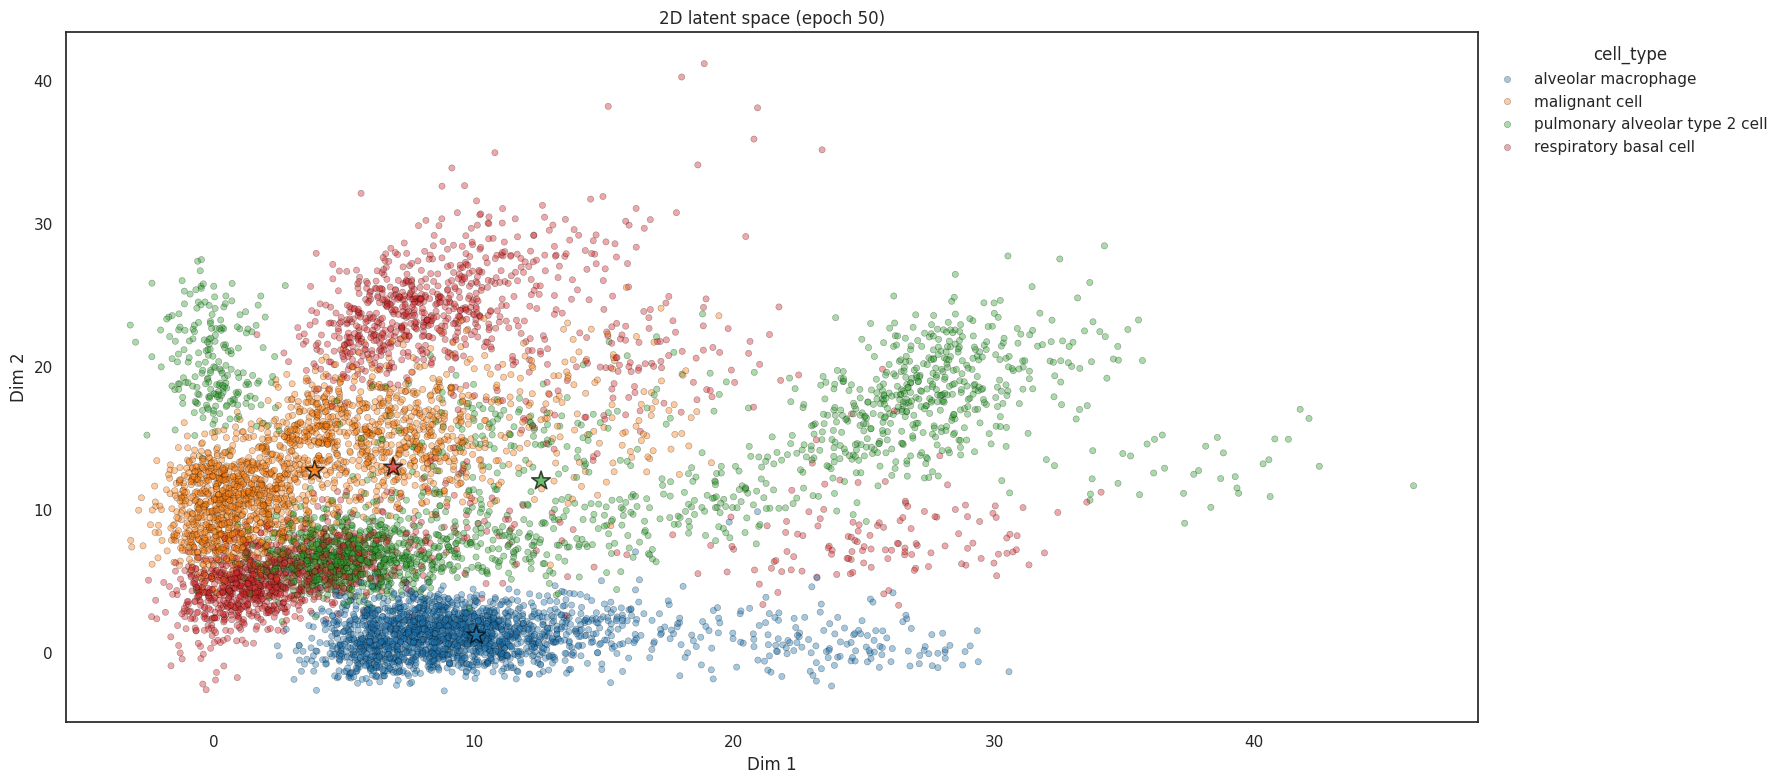

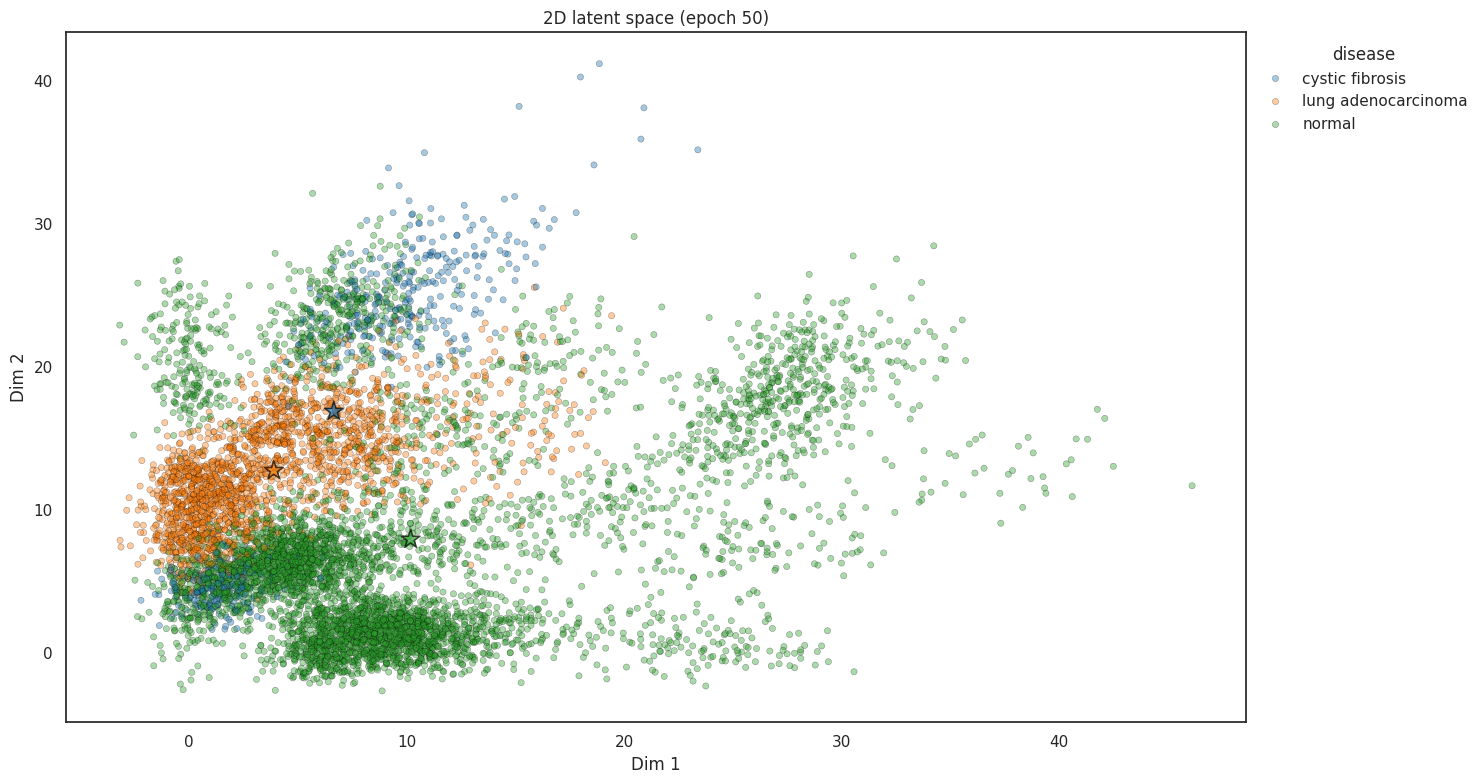

In [22]:

disent.show_result(params=["cell_type", "disease"])


In [23]:
my_cfg2 = DisentanglixConfig(
	data_case=DataCase.MULTI_SINGLE_CELL,
	loss_reduction="sum",
	k_filter=2000,
	latent_dim=2,
	scaling="STANDARD",
	epochs=50,
	learning_rate=0.01,
	batch_size = 128,
	beta_mi = 0.1,
	beta_tc = 100,
	beta_dimKL= 0.01,
	use_mss = True,
	drop_p =0.1,
	global_seed=43,
	reproducible=True,
	checkpoint_interval=10,
	n_layers=1,
	annotation_columns=["cell_type", "disease"],
	data_config=DataConfig(
		data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
	),
)

disent2 = acx.Disentanglix(data=sc_data, config=my_cfg2)

in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


In [24]:
result2 = disent2.run()

mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc
Processing valid split

/home/ewald/Github/autoencodix_package/src/autoencodix/trainers/_general_trainer.py:233: UserWarning: Gradient clipping was first applied in epoch 0. Total norm of gradients (adjusted for number of features): 37.2342 exceeded max norm of 5.
  warnings.warn(


Epoch 10 - Train Loss: 1733.3753
Sub-losses: recon_loss: 1732.9020, mut_info_loss: 0.0008, tot_corr_loss: 0.3315, dimwise_kl_loss: 0.1410, anneal_factor: 0.0017, effective_beta_mi_factor: 0.0002, effective_beta_tc_factor: 0.1659, effective_beta_dimKL_factor: 0.0000
Epoch 10 - Valid Loss: 1950.2923
Sub-losses: recon_loss: 1949.8453, mut_info_loss: 0.0007, tot_corr_loss: 0.3162, dimwise_kl_loss: 0.1301, anneal_factor: 0.0017, effective_beta_mi_factor: 0.0002, effective_beta_tc_factor: 0.1659, effective_beta_dimKL_factor: 0.0000
Epoch 20 - Train Loss: 1728.2531
Sub-losses: recon_loss: 1713.6828, mut_info_loss: 0.0355, tot_corr_loss: 12.1502, dimwise_kl_loss: 2.3845, anneal_factor: 0.0832, effective_beta_mi_factor: 0.0083, effective_beta_tc_factor: 8.3173, effective_beta_dimKL_factor: 0.0008
Epoch 20 - Valid Loss: 1946.6253
Sub-losses: recon_loss: 1934.0889, mut_info_loss: 0.0339, tot_corr_loss: 10.7254, dimwise_kl_loss: 1.7771, anneal_factor: 0.0832, effective_beta_mi_factor: 0.0083, effe

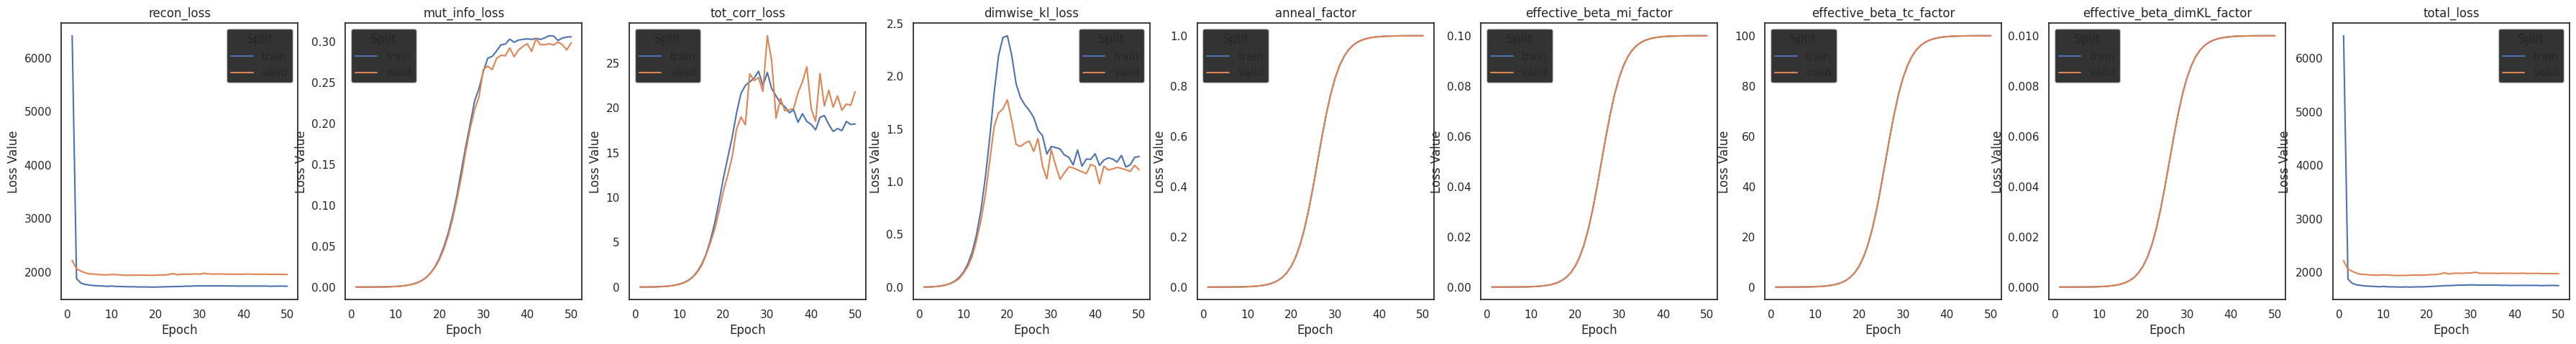

In [25]:
disent2.visualizer.show_loss(plot_type="absolute")

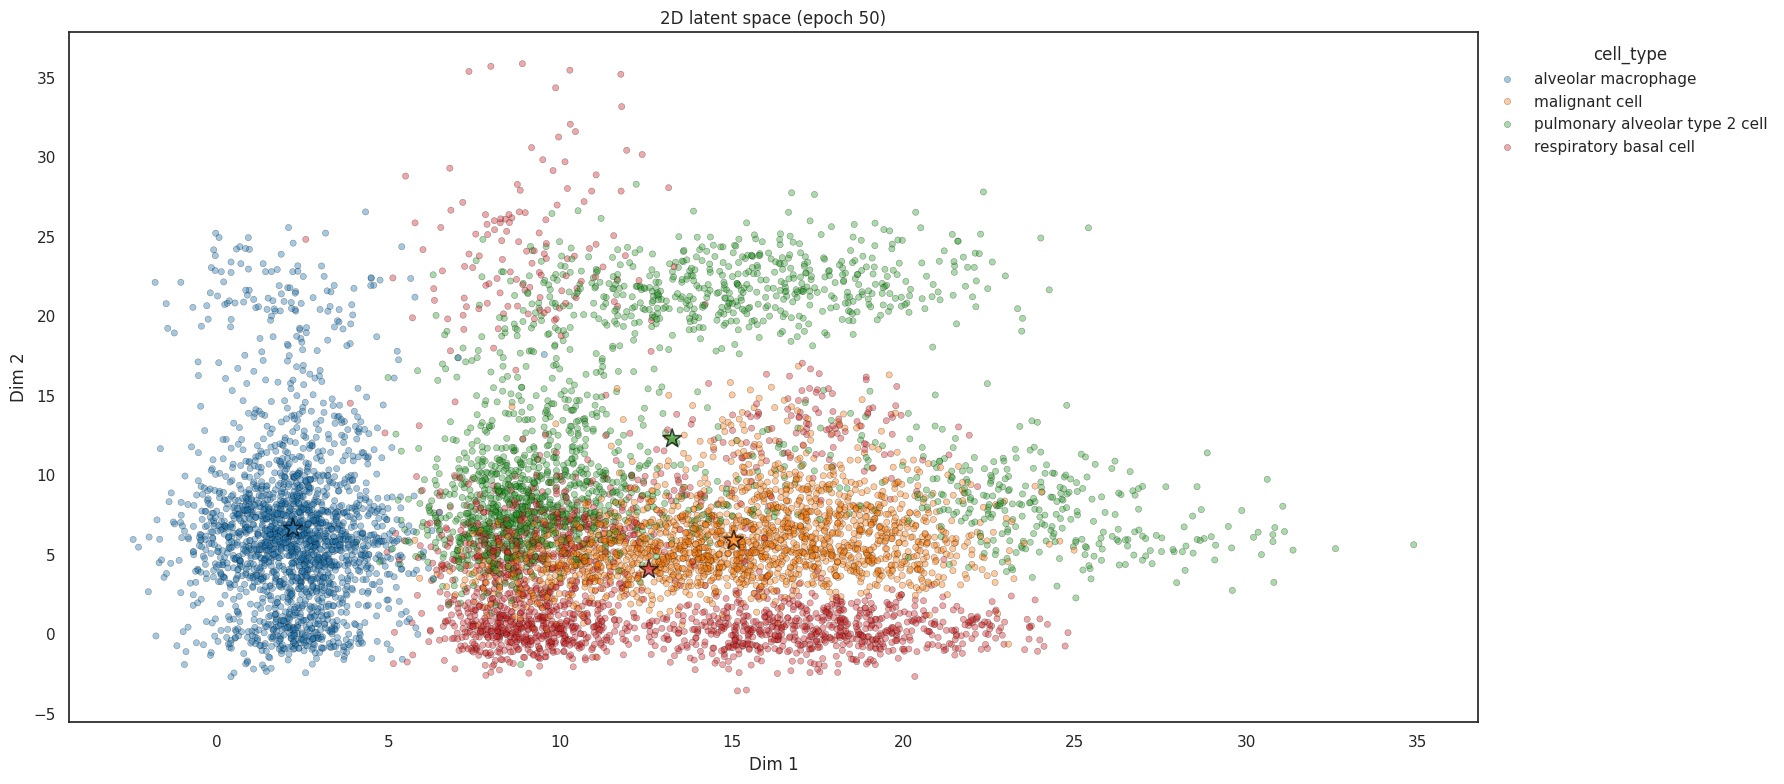

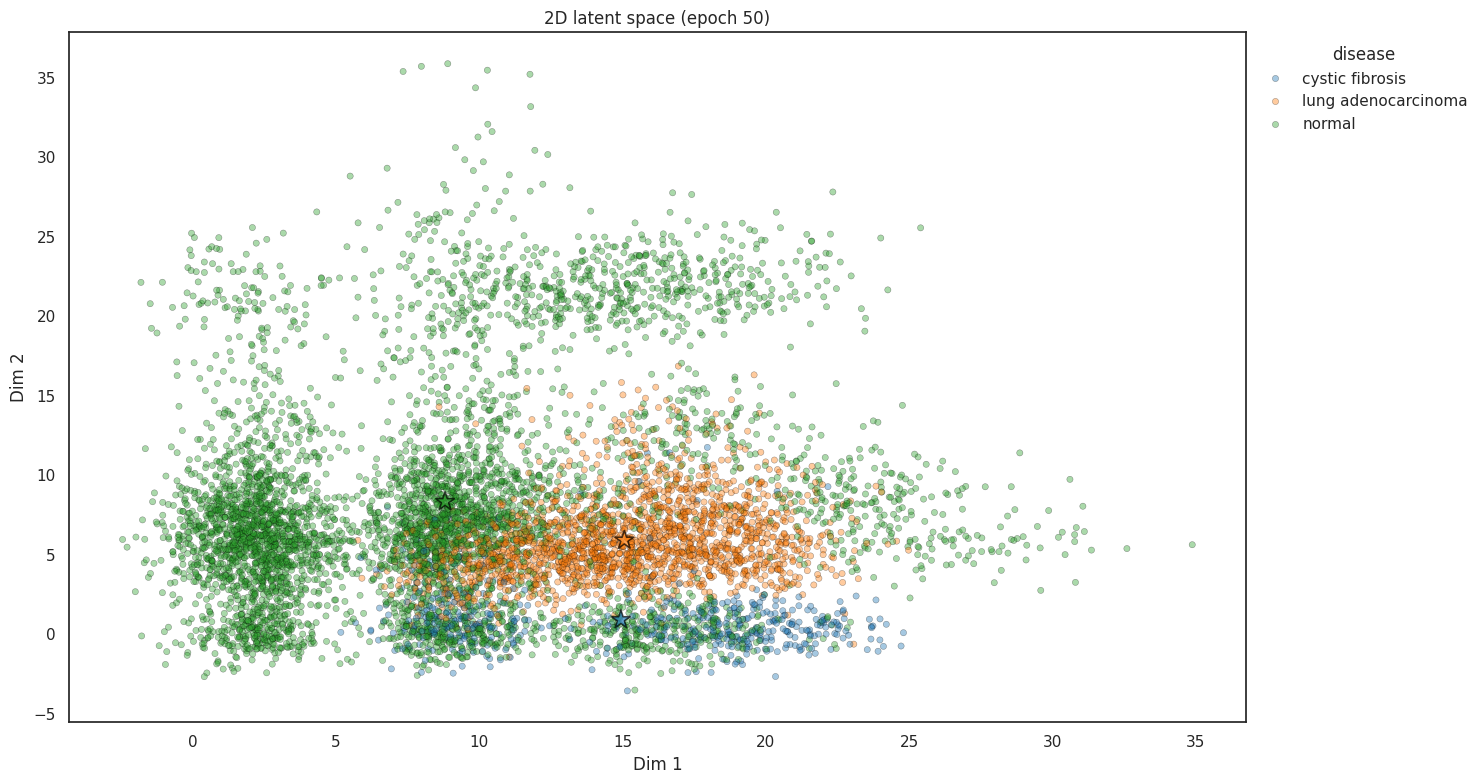

In [26]:
disent2.visualizer.show_latent_space(result=result2, param=["cell_type", "disease"], plot_type="2D-scatter")

#### 3.3) Save and Load Disentanglix

There are not `Disentanglix` specific steps here. See the `Getting Started - Vanillix` for details. Below is a basic save/load usecase:

In [27]:
import glob
import os
outpath = os.path.join("tutorial_res", "disent.pkl")
disent.save(file_path=outpath, save_all=True)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# the load functionality automatically will build the pipeline object out of the three saved files
disent_loaded = acx.Disentanglix.load(outpath)

Preprocessor saved successfully.
Pipeline object saved successfully.
PKL files: ['tutorial_res/varix_preprocessor.pkl', 'tutorial_res/disent.pkl', 'tutorial_res/disent_preprocessor.pkl']
Model files: ['tutorial_res/disent_model.pth', 'tutorial_res/varix_model.pth']
Attempting to load a pipeline from tutorial_res/disent.pkl...
Pipeline object loaded successfully. Actual type: Disentanglix
Preprocessor loaded successfully.


In [28]:
disent_loaded.predict(data=disent.result.datasets)


Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'mut_info_loss': TrainingDynamics(), 'tot_corr_loss': TrainingDynamics(), 'dimwise_kl_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_mi_factor': TrainingDynamics(), 'effective_beta_tc_factor': TrainingDynamics(), 'effective_beta_dimKL_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._numeric_dataset.NumericDataset object at 0x736bd0c73880>, valid=<autoencodix.data._numeric_dataset.NumericDataset object at 0x736b8d98dd20>, test=<autoencodix.data._numeric_dataset.NumericDataset object

Creating plots ...


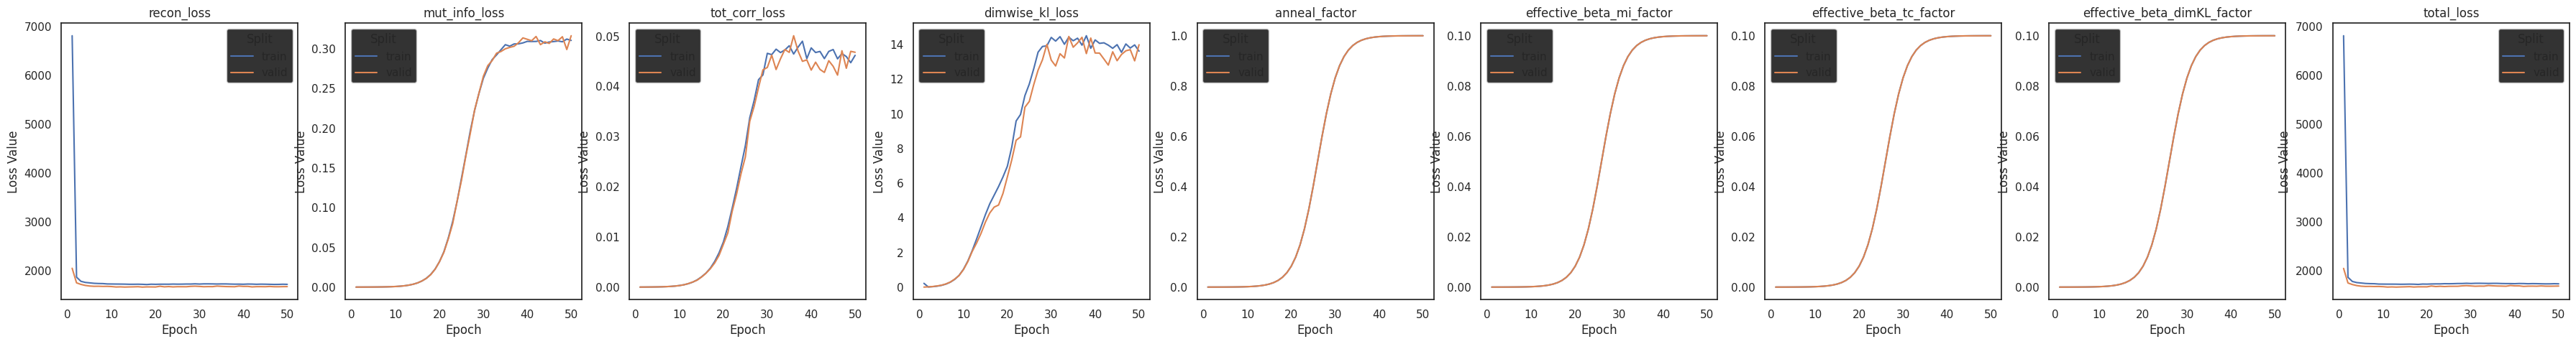

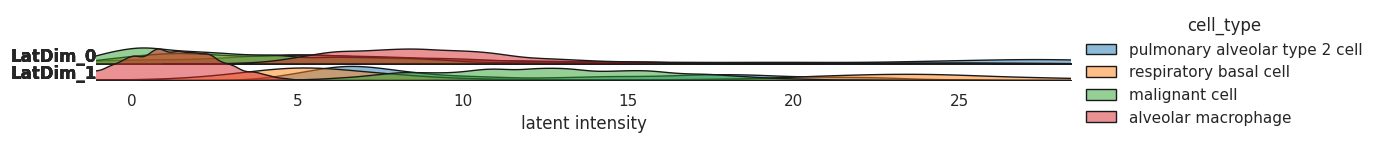

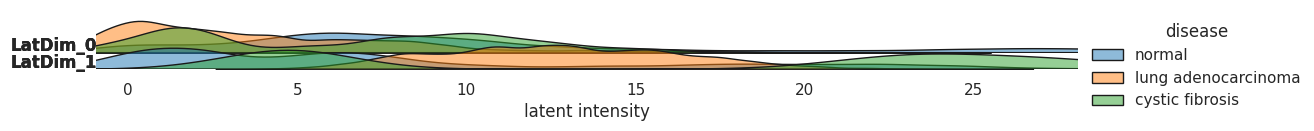

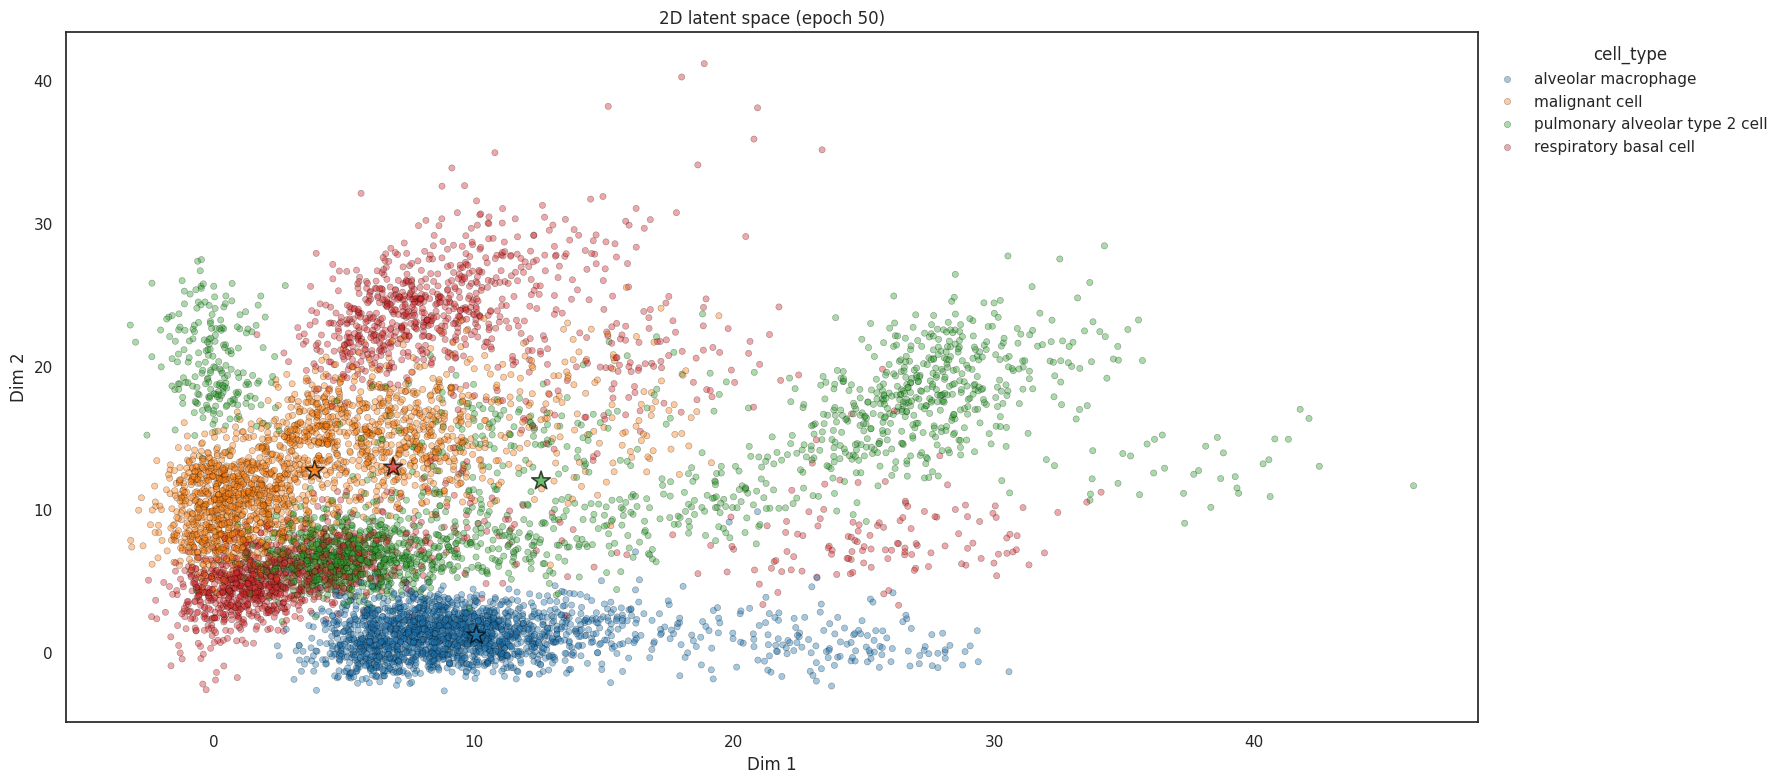

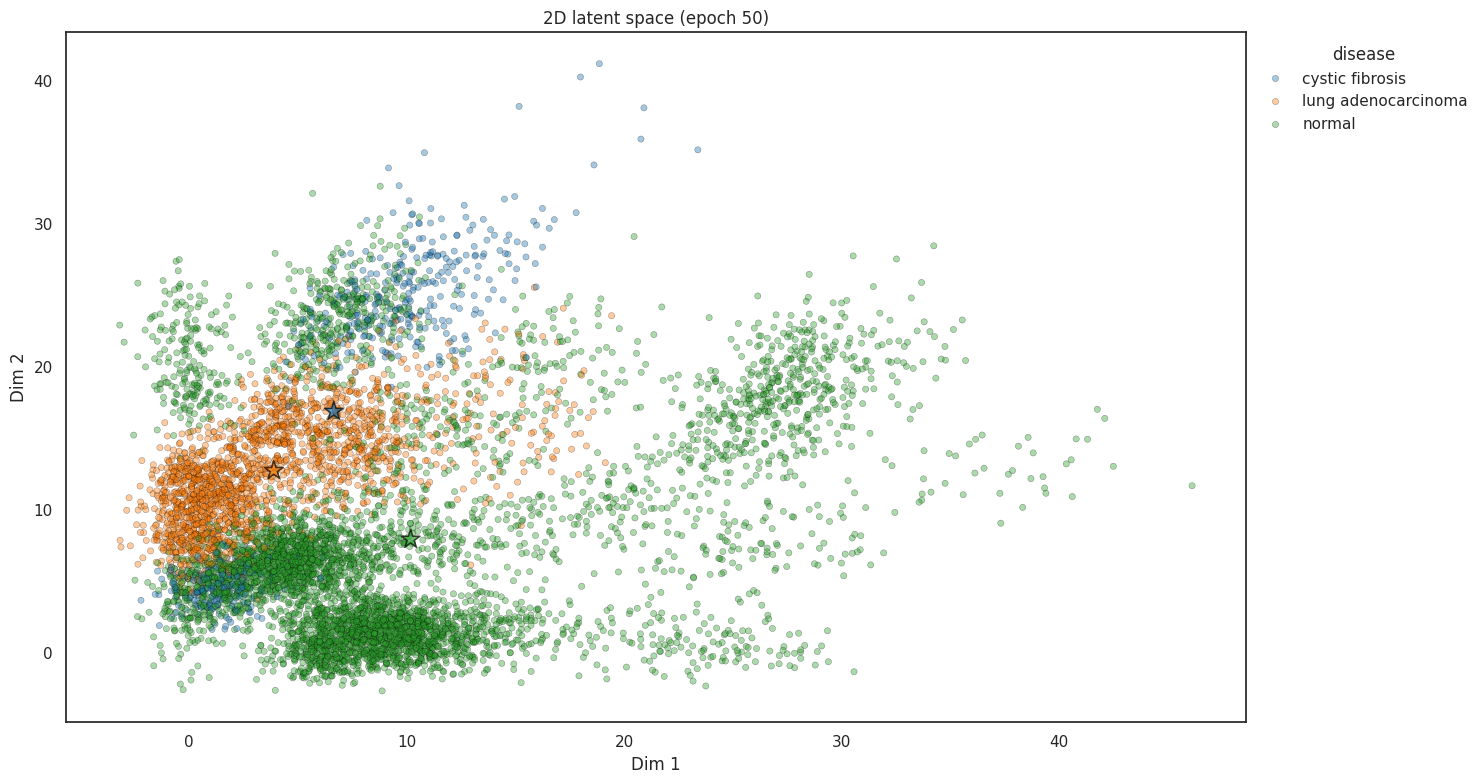

In [29]:

disent_loaded.show_result(params=["cell_type", "disease"])


#### Generate New Data
For a variational autoencoder, the generate or sample_latent_space step draws new latent vectors from the model’s learned latent distribution.

**Latent Sampling:** 
The model first aggregates the posterior over all encoded latent vectors in the chosen split and epoch by computing the mean (global_mu) and log-variance (global_logvar). It then samples new latent points from a diagonal Gaussian defined by these aggregate statistics, using the reparameterization trick to inject Gaussian noise.

**Number of Samples (n_samples):** 
Users can specify how many latent points to generate. The method expands the aggregated mean and log-variance to match the requested number of samples before sampling.

**Custom Latent Prior:** 
Optionally, a custom latent_prior can be provided (a tensor or NumPy array with shape (n_samples, latent_dim)), which will be used directly instead of the aggregated posterior. This is basically the `decode` step.


In [30]:
reconstructions_generated = disent_loaded.generate(n_samples=5)
print(reconstructions_generated.shape)

Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
torch.Size([5, 2000])
